# 01 Data Check: Reading the ECG `.mat` File

This notebook performs the initial inspection of the UofTDB MATLAB file. It loads `ecguoftdb.mat`, lists available variables, checks data types and shapes, identifies the ECG signal container, extracts one example ECG signal, and plots the first 5 seconds.

Data file: `F:\ECG\data\raw\ecguoftdb.mat`

Sampling rate: `200 Hz`, meaning 200 samples per second.


## Step 0: Import Required Python Packages

This section checks the required packages before loading the MATLAB file.

- `scipy.io`: used first for regular MATLAB `.mat` files
- `h5py`: fallback for MATLAB v7.3/HDF5 files
- `numpy`: array processing
- `matplotlib`: ECG waveform plotting


In [1]:
import sys
import subprocess
from pathlib import Path


def install_if_missing(package_name):
    """Install a Python package if it is missing."""
    try:
        __import__(package_name)
    except ImportError:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


for package in ["numpy", "scipy", "h5py", "matplotlib"]:
    install_if_missing(package)

import numpy as np
import matplotlib.pyplot as plt

print("Required packages are ready.")

Required packages are ready.


## Step 1: Set File Paths

The `.mat` file path is stored in `mat_file` so the rest of the notebook can reuse one variable instead of repeating the full path.


In [4]:
mat_file = Path(r"F:\ECG\data\raw\ecguoftdb.mat")

print("MAT file path:", mat_file)
print("File exists:", mat_file.exists())

if not mat_file.exists():
    raise FileNotFoundError("Cannot find ecguoftdb.mat. Please check the file path.")

MAT file path: F:\ECG\data\raw\ecguoftdb.mat
File exists: True


## Step 2: Read the `.mat` File

The notebook first tries `scipy.io.loadmat`. If that fails, it falls back to `h5py.File`. The UofTDB file is usually readable with `scipy.io.loadmat`.


In [7]:
import scipy.io as sio
import h5py

load_method = None
mat_data = None

try:
    # squeeze_me=False: keep MATLAB dimensions unchanged for inspection
    # struct_as_record=False: make MATLAB structs easier to inspect
    mat_data = sio.loadmat(mat_file, squeeze_me=False, struct_as_record=False)
    load_method = "scipy.io.loadmat"
    print("Loaded with method: scipy.io.loadmat")

except NotImplementedError:
    # MATLAB v7.3 files usually need h5py
    mat_data = h5py.File(mat_file, "r")
    load_method = "h5py.File"
    print("scipy.io could not read the file; trying h5py.File")

except Exception as error:
    print("scipy.io failed with error:")
    print(error)
    print("Trying h5py.File now ...")
    mat_data = h5py.File(mat_file, "r")
    load_method = "h5py.File"
    print("Loaded with method: h5py.File")

Loaded with method: scipy.io.loadmat


## Step 3: List Variables in the MATLAB File

After loading a MATLAB file into Python, the result behaves like a dictionary. Variable names are dictionary keys, and variable contents are the corresponding values. System entries that start with `__` are filtered out.


In [10]:
if load_method == "scipy.io.loadmat":
    variable_names = [name for name in mat_data.keys() if not name.startswith("__")]
else:
    variable_names = list(mat_data.keys())

print("Variable names in the file:")
for name in variable_names:
    print("-", name)

Variable names in the file:
- signals


## Step 4: Inspect Variable Types and Shapes

This section checks each variable's Python type, array shape, and dtype to understand the MATLAB structure before extracting ECG signals.


In [13]:
def print_variable_info(name, value):
    """Print shape and dtype information."""
    print(f"Variable name:{name}")
    print(f"  type : {type(value)}")
    print(f"  shape: {getattr(value, 'shape', None)}")
    print(f"  dtype: {getattr(value, 'dtype', None)}")
    print()


print("Basic information for each variable:")
print("=" * 50)

for name in variable_names:
    value = mat_data[name]
    print_variable_info(name, value)

Basic information for each variable:
Variable name:signals
  type : <class 'numpy.ndarray'>
  shape: (1, 1020)
  dtype: object



## Step 5: Identify the ECG Signal Variable

According to `ecgUofTDB guide.rtf`, the ECG data are organized in the `signals` cell array. If `signals` is available, it is treated as the main ECG signal container. Otherwise, the notebook falls back to searching for a large numeric array.


In [16]:
if "signals" in variable_names:
    ecg_variable_name = "signals"
    print("Decision result: using 'signals' as the ECG array.")
else:
    ecg_variable_name = None
    for name in variable_names:
        value = mat_data[name]
        if hasattr(value, "shape") and hasattr(value, "dtype"):
            if np.issubdtype(value.dtype, np.number) and value.size > 1000:
                ecg_variable_name = name
                break

    if ecg_variable_name is None:
        raise ValueError("Cannot find an ECG signal array. Please inspect variable names.")
    else:
        print(f"Found no 'signals' variable, so using '{ecg_variable_name}' as the ECG array.")

ecg_data = mat_data[ecg_variable_name]
print("ECG main variable name:", ecg_variable_name)
print("ECG main variable shape:", getattr(ecg_data, "shape", None))
print("ECG main variable dtype:", getattr(ecg_data, "dtype", None))

Decision result: using 'signals' as the ECG array.
ECG main variable name: signals
ECG main variable shape: (1, 1020)
ECG main variable dtype: object


## Step 6: Extract One ECG Signal

The `signals` variable is a nested MATLAB cell array containing subject, week, and condition levels. This section searches inside the nested structure for the first numeric array that is long enough to represent an ECG signal.


In [19]:
def find_first_numeric_signal(x, path="signals", min_length=1000):
    """
    Collect numeric ECG arrays from nested MATLAB cell-array-like objects.

    Parameters:
    - x:current object to inspect
    - path: traversal path used for debugging
    - min_length: minimum length required for an ECG signal candidate

    Returns:
    - when found, returns (location description, numeric array)
    - when not found, returns (None, None)
    """
    # Case 1:if it is a NumPy array
    if isinstance(x, np.ndarray):
        # Follow nested arrays and object containers recursively
        if x.dtype != object and np.issubdtype(x.dtype, np.number) and x.size >= min_length:
            return path, x

        # Object dtype often indicates MATLAB cell arrays, so recurse into elements
        if x.dtype == object:
            for index, item in np.ndenumerate(x):
                found_path, found_signal = find_first_numeric_signal(
                    item,
                    path=f"{path}{index}",
                    min_length=min_length,
                )
                if found_signal is not None:
                    return found_path, found_signal

    # Case 2: h5py Dataset; convert it to a NumPy array
    if load_method == "h5py.File" and isinstance(x, h5py.Dataset):
        array = np.array(x)
        if np.issubdtype(array.dtype, np.number) and array.size >= min_length:
            return path, array

    # Case 3: h5py Group; recurse into members
    if load_method == "h5py.File" and isinstance(x, h5py.Group):
        for key in x.keys():
            found_path, found_signal = find_first_numeric_signal(
                x[key],
                path=f"{path}/{key}",
                min_length=min_length,
            )
            if found_signal is not None:
                return found_path, found_signal

    return None, None


signal_path, raw_signal = find_first_numeric_signal(ecg_data, path=ecg_variable_name)

if raw_signal is None:
    raise ValueError("No ECG signal candidates were found.")

print("Location of one ECG signal:", signal_path)
print("Raw signal shape:", raw_signal.shape)
print("Raw signal dtype:", raw_signal.dtype)

Location of one ECG signal: signals(0, 0)(0, 0)(0, 0)
Raw signal shape: (24001, 1)
Raw signal dtype: float64


## Step 7: Convert the Signal to a One-dimensional Array

ECG plotting is easiest with a one-dimensional array, such as `[sample_1, sample_2, sample_3, ...]`. If the loaded signal has shape `(N, 1)` or `(1, N)`, `squeeze()` removes the extra dimension.


In [22]:
ecg_signal = np.asarray(raw_signal).squeeze()

# Remove singleton dimensions and normalize the orientation.
# Rows are treated as individual ECG records.
if ecg_signal.ndim == 2:
    if ecg_signal.shape[0] >= ecg_signal.shape[1]:
        ecg_signal = ecg_signal[:, 0]
    else:
        ecg_signal = ecg_signal[0, :]

if ecg_signal.ndim != 1:
    raise ValueError(f"Unexpected ECG array shape: {ecg_signal.shape}")

print("One-dimensional ECG signal shape after processing:", ecg_signal.shape)
print("First 10 samples:")
print(ecg_signal[:10])

One-dimensional ECG signal shape after processing: (24001,)
First 10 samples:
[0.994 1.008 1.235 1.06  0.985 1.168 1.149 1.004 1.134 1.304]


## Step 8: Plot the First 5 Seconds of ECG

The sampling rate is `200 Hz`, so 5 seconds correspond to `200 * 5 = 1000` samples. This section plots the first 1000 samples.


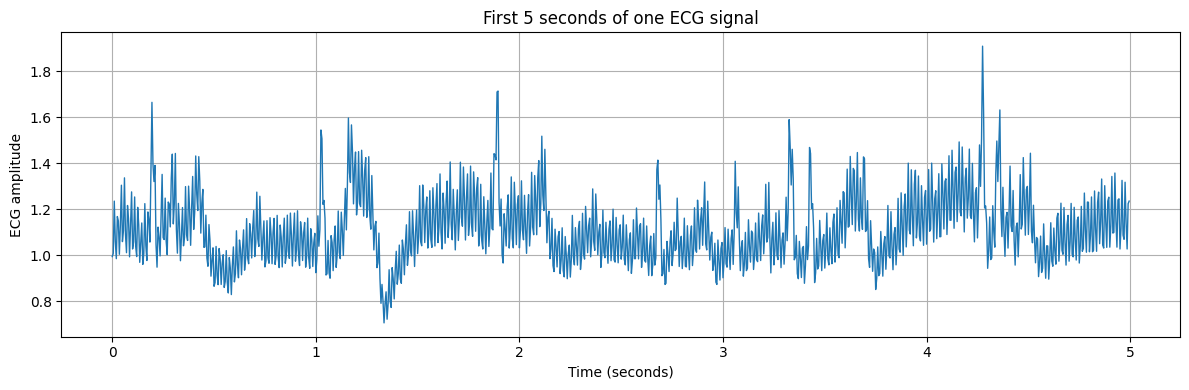

In [25]:
sampling_rate = 200
seconds_to_plot = 5
num_points = sampling_rate * seconds_to_plot

ecg_5s = ecg_signal[:num_points]
time_axis = np.arange(len(ecg_5s)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(time_axis, ecg_5s, linewidth=1)
plt.title("First 5 seconds of one ECG signal")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

# 1. Read the .mat file
mat_path = (r"F:\ECG\data\raw\ecguoftdb.mat")
mat = loadmat(mat_path)

signals = mat["signals"]

# 2. Basic parameters
fs = 200  # sampling rate reported in the UofTDB guide
condition_map = {
    1: "sit",
    2: "stand",
    3: "exercise",
    4: "supine",
    5: "tripod"
}

records = []
record_number = 1

# 3. Iterate over subjects
for subject_index in range(signals.shape[1]):
    subject_id = subject_index + 1
    subject_cell = signals[0, subject_index]

    # Skip empty subjects
    if subject_cell is None:
        continue

    # Some cells may be empty arrays
    if isinstance(subject_cell, np.ndarray) and subject_cell.size == 0:
        continue

    # 4. Iterate over weeks
    # Reminder: inspect the MAT structure if these fields are missing
    try:
        weeks = subject_cell[0]
    except Exception:
        weeks = subject_cell

    for week_index in range(len(weeks)):
        week_number = week_index + 1

        try:
            week_cell = weeks[week_index]
        except Exception:
            continue

        if week_cell is None:
            continue

        if isinstance(week_cell, np.ndarray) and week_cell.size == 0:
            continue

        # 5. Iterate over conditions
        try:
            conditions = week_cell[0]
        except Exception:
            conditions = week_cell

        for condition_index in range(len(conditions)):
            condition_number = condition_index + 1
            condition_name = condition_map.get(condition_number, "unknown")

            try:
                ecg = conditions[condition_index]
            except Exception:
                continue

            if ecg is None:
                continue

            ecg = np.asarray(ecg).squeeze()

            # Skip empty ECG entries
            if ecg.size == 0:
                continue

            signal_length = len(ecg)
            duration_seconds = signal_length / fs

            records.append({
                "record_number": record_number,
                "subject_id": subject_id,
                "week_number": week_number,
                "condition_number": condition_number,
                "condition_name": condition_name,
                "signal_length_samples": signal_length,
                "duration_seconds": duration_seconds,
                "signal_index_path": f"signals[0,{subject_index}][week={week_index}][condition={condition_index}]"
            })

            record_number += 1

# 6. Convert to a table
metadata = pd.DataFrame(records)

# 7. Inspect the first rows
metadata.head(20)

,record_number,subject_id,week_number,condition_number,condition_name,signal_length_samples,duration_seconds,signal_index_path
0,1,1,1,1,sit,24001,120.005,"signals[0,0][week=0][condition=0]"
1,2,2,1,1,sit,24001,120.005,"signals[0,1][week=0][condition=0]"
2,3,3,1,1,sit,24001,120.005,"signals[0,2][week=0][condition=0]"
3,4,4,1,1,sit,24001,120.005,"signals[0,3][week=0][condition=0]"
4,5,5,1,1,sit,24001,120.005,"signals[0,4][week=0][condition=0]"
5,6,6,1,1,sit,17613,88.065,"signals[0,5][week=0][condition=0]"
6,7,7,1,1,sit,18735,93.675,"signals[0,6][week=0][condition=0]"
7,8,8,1,1,sit,5087,25.435,"signals[0,7][week=0][condition=0]"
8,9,9,1,1,sit,22617,113.085,"signals[0,8][week=0][condition=0]"
9,10,10,1,1,sit,12001,60.005,"signals[0,9][week=0][condition=0]"


In [29]:
# 8. Export metadata to the target path
output_path = r"F:\ECG\data\raw\ecguoftdb.csv"

metadata.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"metadata exported successfully to: {output_path}")
print("number of exported records:", len(metadata))

metadata exported successfully to: F:\ECG\data\raw\ecguoftdb.csv
number of exported records: 1627


In [31]:
import pandas as pd

# First build metadata from the MAT file when available
# If no metadata table exists, create a fallback CSV:
# metadata = pd.read_csv("../data/processed/metadata_records.csv")

# Count how many ECG records each subject has
subject_record_counts = (
    metadata
    .groupby("subject_id")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

# Filter subjects with multiple records
multi_record_subjects = subject_record_counts[
    subject_record_counts["record_count"] > 1
]

print("number of subjects with multiple ECG records:", len(multi_record_subjects))
print("maximum record count:", multi_record_subjects["record_count"].max())

multi_record_subjects.head(20)

number of subjects with multiple ECG records: 90
maximum record count: 10


,subject_id,record_count
523,525,10
594,596,10
412,414,10
407,408,10
631,633,10
873,875,10
658,660,10
660,662,10
668,670,10
674,676,10


In [33]:
# Extract detailed metadata for all subjects with multiple records
multi_record_details = metadata[
    metadata["subject_id"].isin(multi_record_subjects["subject_id"])
].sort_values(["subject_id", "week_number", "condition_number"])

multi_record_details.head(50)

,record_number,subject_id,week_number,condition_number,condition_name,signal_length_samples,duration_seconds,signal_index_path
218,219,219,1,1,sit,24001,120.005,"signals[0,218][week=0][condition=0]"
219,220,219,3,1,sit,24000,120.000,"signals[0,218][week=2][condition=0]"
220,221,219,3,3,exercise,24000,120.000,"signals[0,218][week=2][condition=2]"
221,222,219,4,1,sit,60000,300.000,"signals[0,218][week=3][condition=0]"
235,236,233,1,1,sit,12000,60.000,"signals[0,232][week=0][condition=0]"
236,237,233,2,1,sit,24000,120.000,"signals[0,232][week=1][condition=0]"
237,238,233,2,2,stand,12000,60.000,"signals[0,232][week=1][condition=1]"
238,239,233,3,1,sit,24000,120.000,"signals[0,232][week=2][condition=0]"
239,240,233,3,2,stand,24000,120.000,"signals[0,232][week=2][condition=1]"
240,241,233,4,1,sit,60000,300.000,"signals[0,232][week=3][condition=0]"


In [35]:
multi_record_details.to_csv(
    r"F:\ECG\data\raw\multi_record_details.csv",
    index=False
)

print("saved to F:/ECG/data/raw/multi_record_details.csv")

saved to F:/ECG/data/raw/multi_record_details.csv


In [36]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from scipy.io import loadmat

# =========================
# 1. Load metadata
# =========================

mat_path = Path(r"F:\ECG\data\raw\ecguoftdb.mat")

# metadata CSV that was already exported
metadata_path = Path(r"F:\ECG\data\raw\ecguoftdb.csv")

# recommend storing the PKL under processed
output_pkl_path = Path(r"F:\ECG\data\raw\signals_raw.pkl")
output_pkl_path.parent.mkdir(parents=True, exist_ok=True)

# =========================
# 2. Reconcile MAT metadata
# =========================

mat = loadmat(mat_path)
signals = mat["signals"]

metadata = pd.read_csv(metadata_path)

print("signals shape:", signals.shape)
print("metadata rows:", len(metadata))

# =========================
# 3. Prepare condition mapping
# =========================

condition_map = {
    1: "sit",
    2: "stand",
    3: "exercise",
    4: "supine",
    5: "tripod"
}

# =========================
# 4. Load ECG signals from the MAT file
# =========================

extracted_signals = {}
record_number = 1

for subject_index in range(signals.shape[1]):
    subject_id = subject_index + 1
    subject_cell = signals[0, subject_index]

    # Skip empty subjects
    if subject_cell is None:
        continue

    if isinstance(subject_cell, np.ndarray) and subject_cell.size == 0:
        continue

    # Parse the week level
    try:
        weeks = subject_cell[0]
    except Exception:
        weeks = subject_cell

    for week_index in range(len(weeks)):
        week_number = week_index + 1

        try:
            week_cell = weeks[week_index]
        except Exception:
            continue

        if week_cell is None:
            continue

        if isinstance(week_cell, np.ndarray) and week_cell.size == 0:
            continue

        # Parse the condition level
        try:
            conditions = week_cell[0]
        except Exception:
            conditions = week_cell

        for condition_index in range(len(conditions)):
            condition_number = condition_index + 1
            condition_name = condition_map.get(condition_number, "unknown")

            try:
                ecg = conditions[condition_index]
            except Exception:
                continue

            if ecg is None:
                continue

            ecg = np.asarray(ecg).squeeze()

            # Skip empty ECG entries
            if ecg.size == 0:
                continue

            # Save the one-dimensional ECG signal
            extracted_signals[record_number] = ecg

            record_number += 1

# =========================
# 5. Save PKL
# =========================

with open(output_pkl_path, "wb") as f:
    pickle.dump(extracted_signals, f)

print("PKL saved to:", output_pkl_path)
print("number of ECG records in PKL:", len(extracted_signals))

signals shape: (1, 1020)
metadata rows: 1627
PKL saved to: F:\ECG\data\raw\signals_raw.pkl
number of ECG records in PKL: 1627


In [38]:
# =========================
# 6. Check whether CSV and PKL are synchronized
# =========================

print("metadata record count:", len(metadata))
print("PKL ECG count:", len(extracted_signals))

if len(metadata) == len(extracted_signals):
    print("[OK] metadata CSV and PKL counts match")
else:
    print("[WARNING] No record_count variable found")

# Check whether record_number values match one-to-one
metadata_record_numbers = set(metadata["record_number"].astype(int))
pkl_record_numbers = set(extracted_signals.keys())

missing_in_pkl = metadata_record_numbers - pkl_record_numbers
extra_in_pkl = pkl_record_numbers - metadata_record_numbers

print("record_number count present in CSV but missing in PKL:", len(missing_in_pkl))
print("record_number count present in PKL but missing in CSV:", len(extra_in_pkl))

# Inspect the shape of the first five ECG records
for rn in list(extracted_signals.keys())[:5]:
    print(f"record_number {rn}, signal shape: {extracted_signals[rn].shape}")

metadata record count: 1627
PKL ECG count: 1627
[OK] metadata CSV and PKL counts match
record_number count present in CSV but missing in PKL: 0
record_number count present in PKL but missing in CSV: 0
record_number 1, signal shape: (24001,)
record_number 2, signal shape: (24001,)
record_number 3, signal shape: (24001,)
record_number 4, signal shape: (24001,)
record_number 5, signal shape: (24001,)


In [40]:
record_id = 1

# Inspect the guide
display(metadata[metadata["record_number"] == record_id])

# Inspect the real ECG signal
signal = extracted_signals[record_id]

print("Signal shape:", signal.shape)
print("First 10 values:", signal[:10])

,record_number,subject_id,week_number,condition_number,condition_name,signal_length_samples,duration_seconds,signal_index_path
0,1,1,1,1,sit,24001,120.005,"signals[0,0][week=0][condition=0]"


Signal shape: (24001,)
First 10 values: [0.994 1.008 1.235 1.06  0.985 1.168 1.149 1.004 1.134 1.304]


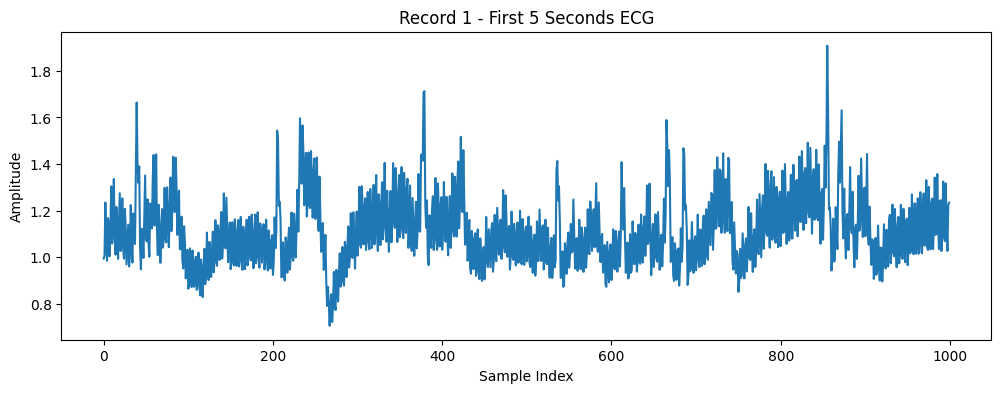

In [42]:
import matplotlib.pyplot as plt

record_id = 1
signal = extracted_signals[record_id]

fs = 200
n = fs * 5

plt.figure(figsize=(12, 4))
plt.plot(signal[:n])
plt.title(f"Record {record_id} - First 5 Seconds ECG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

## Step 9: Inspect the Overall Dataset

The UofTDB MATLAB file is not a regular two-dimensional table. Its `signals` structure can be understood as nested levels for subject, week, condition, and ECG signal. The notebook converts each detected ECG signal into one summary row with clear metadata columns.


## Step 10: Organize Overall Information into a Table

This section creates one summary row for each ECG record, including record number, subject ID, week number, condition number, condition name, signal shape, signal length, and approximate duration.


## Step 11: Show the First Rows and Dataset Size

`head(10)` displays the first 10 rows, and `len(summary_df)` gives the total number of ECG records in the organized dataset.


## Step 12: Convert the Full `.mat` File into a CSV-style Dataset

Because each ECG record is a waveform array, a long-table format is used if a sample-level CSV is needed. Each row represents one ECG sample point with record, subject, week, condition, time, and ECG value fields.


## Step 13: Quickly Check the Generated CSV File

After conversion, the notebook reads the first 10 rows to confirm that the generated CSV file can be opened correctly.


## Step 14: Identify ECG Segments from the Same Person

The first level of the `signals` cell array represents subjects. Therefore, multiple ECG records under the same `subject_id` correspond to multiple ECG segments from the same person.


## Step 15: Count ECG Segments per Subject

This section summarizes every subject with the number of ECG segments, total duration, minimum duration, maximum duration, and sampling rate.


## Step 16: Inspect All ECG Segments for One Subject

Change `target_subject_id` to inspect another subject, such as subject 1, subject 30, or subject 100.


## Summary

If the plots above display correctly, the basic data check has succeeded: the `.mat` file can be read by Python, the variable names have been inspected, `signals` has been identified as the main ECG container, one ECG signal has been extracted, and the first 5-second waveform has been plotted. The next step is usually `02_preprocessing.ipynb`.
